In [117]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr

# Single gene-trait association plots

In [118]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'
# gene_name = 'APOB'

In [119]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [124]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -0
max_range = +100

anno = (
    anno
    .filter(
        filter_expression &

        # (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0) &
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)

        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Filter to gene
        (pl.col('gene_name') == gene_name) &
        
        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

am_pathogenicity,absplice_dna_max,pangolin_score,promoterai,esmscoremissense,delta_score,verphylop,TSS,promoterai_abs,loftee_hc,absplice2_max,Strand,gene_length,gpn_star_llr_calibrated_mean,mamphylop,region,gpn_score,cadd_raw,abexp_min,gene_name,dist_to_tss,id
f32,f32,f32,f32,f32,f32,f32,i64,f32,i8,f32,cat,i64,f64,f32,str,f32,f32,f64,str,i64,str
0.0787,0.003,0.0,-0.0048,-4.076,0.0,1.435,11089461,0.0048,0,0.000428,"""+""",44360,-3.747704,1.499,"""ENSG00000130164""",-4.51,1.838762,-0.04167,"""LDLR""",15762,"""chr19:11105223:C:T"""
0.1016,0.004,0.0,0.0,-5.137,0.0,0.579,11089461,0.0,0,0.000348,"""+""",44360,-2.076928,0.14,"""ENSG00000130164""",-2.96,0.58935,-0.016813,"""LDLR""",33877,"""chr19:11123338:C:T"""
0.4407,0.004,0.03,0.0,-8.95,0.0,0.145,11089461,0.0,0,0.002906,"""+""",44360,-5.406721,-0.724,"""ENSG00000130164""",-6.96,3.30466,-0.111923,"""LDLR""",31046,"""chr19:11120507:A:G"""
0.9894,0.005,0.01,0.0,-10.131,0.01,8.641,11089461,0.0,0,0.002717,"""+""",44360,-7.162505,3.366,"""ENSG00000130164""",-9.39,4.537427,-0.111923,"""LDLR""",13293,"""chr19:11102754:A:G"""
0.1227,0.003,0.01,0.0,-7.606,0.0,2.619,11089461,0.0,0,0.000348,"""+""",44360,-3.934923,1.879,"""ENSG00000130164""",-5.51,3.247835,-0.057597,"""LDLR""",17988,"""chr19:11107449:T:A"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0731,0.092,0.41,-0.0283,-3.714,0.22,-0.064,11089461,0.0283,0,0.380601,"""+""",44360,0.800268,-0.075,"""ENSG00000130164""",-0.85,1.002049,-0.347555,"""LDLR""",16139,"""chr19:11105600:G:A"""
0.2502,0.003,0.0,0.0,-10.321,0.0,7.284,11089461,0.0,0,0.000371,"""+""",44360,-7.1326,2.905,"""ENSG00000130164""",-9.18,4.153654,-0.069889,"""LDLR""",21229,"""chr19:11110690:C:A"""
0.4117,0.003,0.01,-0.0239,-10.209,0.01,1.369,11089461,0.0239,0,0.002202,"""+""",44360,-5.880992,2.767,"""ENSG00000130164""",-5.54,4.749627,-0.122196,"""LDLR""",15788,"""chr19:11105249:C:T"""


In [125]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11105223:C:T""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11123338:C:T""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11120507:A:G""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11102754:A:G""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11107449:T:A""","""ENSG00000130164""","""loftee_hc""",0.0
…,…,…,…
"""chr19:11105600:G:A""","""ENSG00000130164""","""promoterai""",-0.0283
"""chr19:11110690:C:A""","""ENSG00000130164""","""promoterai""",0.0
"""chr19:11105249:C:T""","""ENSG00000130164""","""promoterai""",-0.0239


In [126]:
# Get phenotype data for the phenotype of interest
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet").filter(pl.col('phenotype') == phenotype).collect(engine='streaming')

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u32,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr19:11120507:A:G""","""ldl_direct_int""",3,0.160916,0.659443,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",31046
"""chr19:11102754:A:G""","""ldl_direct_int""",1,3.173926,null,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",13293
"""chr19:11107449:T:A""","""ldl_direct_int""",2,-0.727617,0.184266,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",17988
"""chr19:11105460:G:C""","""ldl_direct_int""",1,-1.624939,null,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",15999
"""chr19:11123327:T:G""","""ldl_direct_int""",8,-0.107919,0.90582,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",33866
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11120114:T:C""","""ldl_direct_int""",29,0.467994,0.943072,"""ENSG00000130164""","""promoterai""",0.0,11089461,"""+""",44360,"""LDLR""",30653
"""chr19:11113409:A:G""","""ldl_direct_int""",5,1.444889,0.880838,"""ENSG00000130164""","""promoterai""",0.0,11089461,"""+""",44360,"""LDLR""",23948
"""chr19:11123229:C:G""","""ldl_direct_int""",1,1.674384,null,"""ENSG00000130164""","""promoterai""",0.0,11089461,"""+""",44360,"""LDLR""",33768


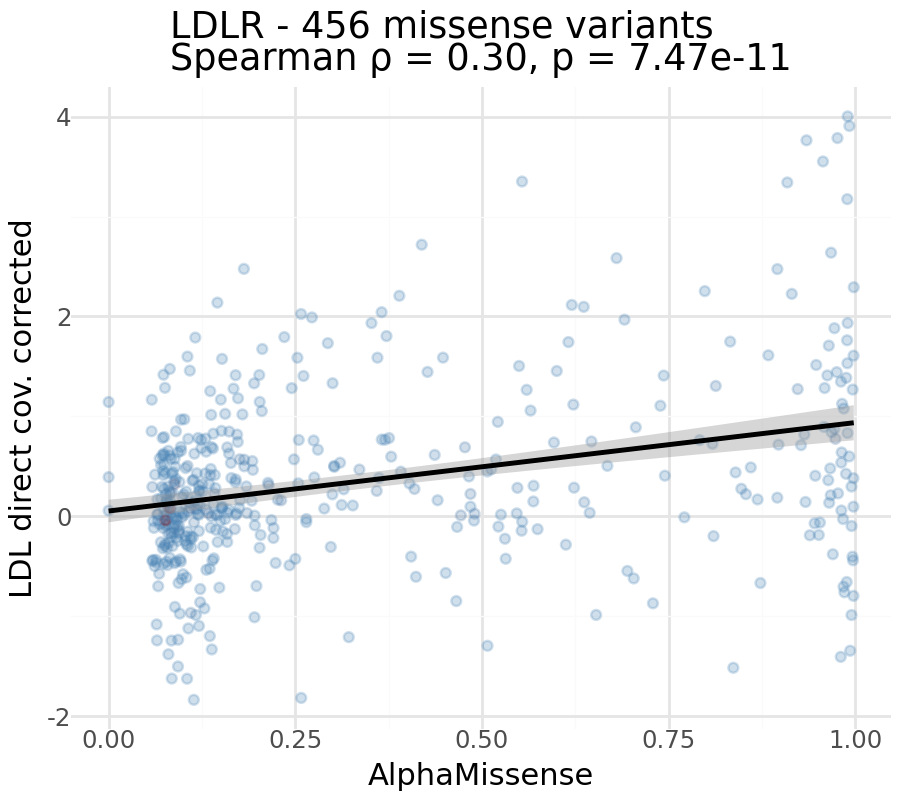

In [129]:
annotation = 'gpn_star_llr_calibrated_mean'
annotation = 'am_pathogenicity'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
    .drop_nulls(subset=['annotation_score', 'mean_pheno_value'])
)

spearman_corr, p_value = spearmanr(
        plot_df['annotation_score'],
        plot_df['mean_pheno_value']
    )

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    stat_smooth(method='glm', se=True) +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} - {plot_df.shape[0]} {variant_class} variants\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
    ) +
    theme(
        figure_size=(4.5, 4),
        legend_position='none'
    )
)

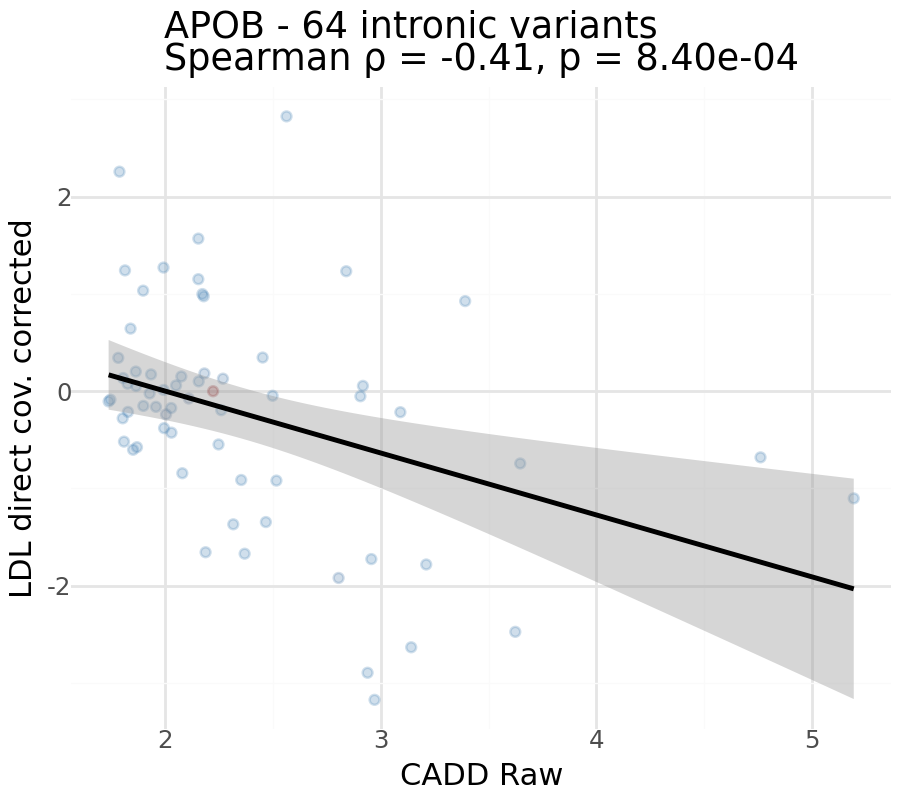

In [93]:
hi_df = (
    plot_df
    # C. Compute rank and percentile in a single, combined step
    .with_columns(
        # Use *[...] to create and unpack a list of expressions
        *[
            expression
            for c in ['annotation_score', 'mean_pheno_value']
            
            for expression in [
                # Expression 1: Rank
                pl.col(c).rank("average").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank"),
                
                # Expression 2: Percentile
                (pl.col(c).rank("average").over(["region", "phenotype", "annotation"]) / pl.col(c).count().over(["region", "phenotype", "annotation"])).alias(f"{c}_percentile")
            ]
        ]
    )
)

plot_hi = hi_df.filter(
    # (pl.col('annotation_score_percentile')<0.01) |
    (pl.col('annotation_score_percentile')>0.99)
)

spearman_corr, p_value = spearmanr(
        plot_hi['annotation_score'],
        plot_hi['mean_pheno_value']
    )

(
    ggplot(plot_hi, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    stat_smooth(method='lm', se=True) +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} - {plot_hi.shape[0]} {variant_class} variants\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
    ) +
    theme(
        figure_size=(4.5, 4),
        legend_position='none'
    )
)

## Other annotations

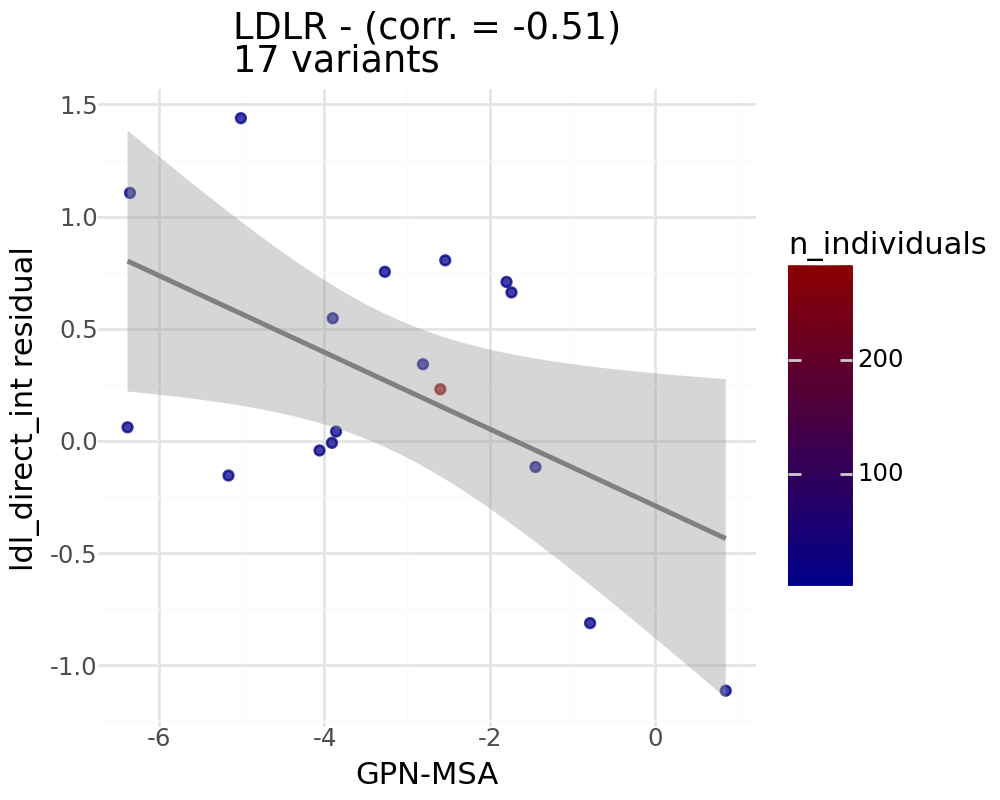

In [43]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

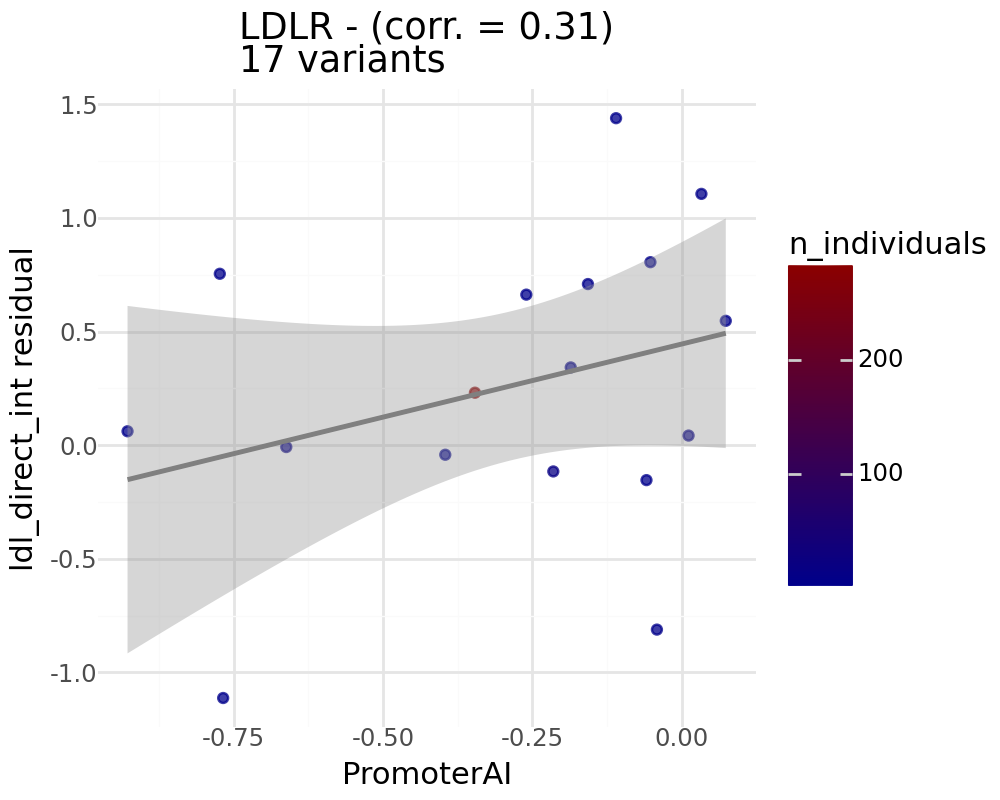

In [44]:
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

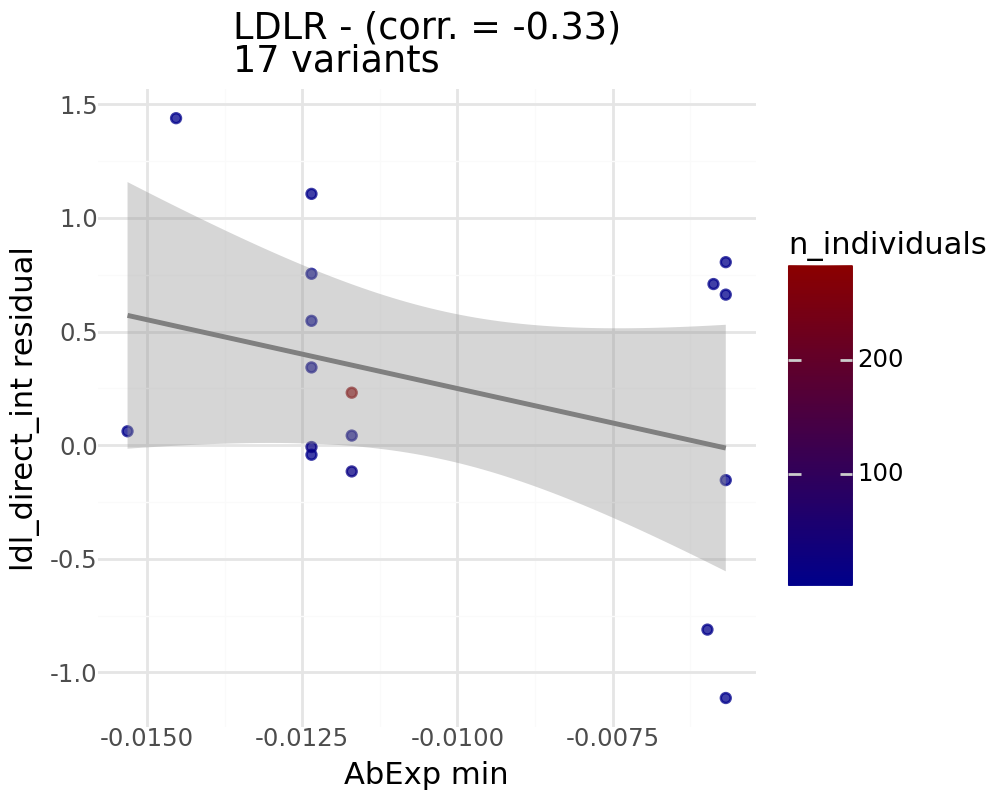

In [45]:
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

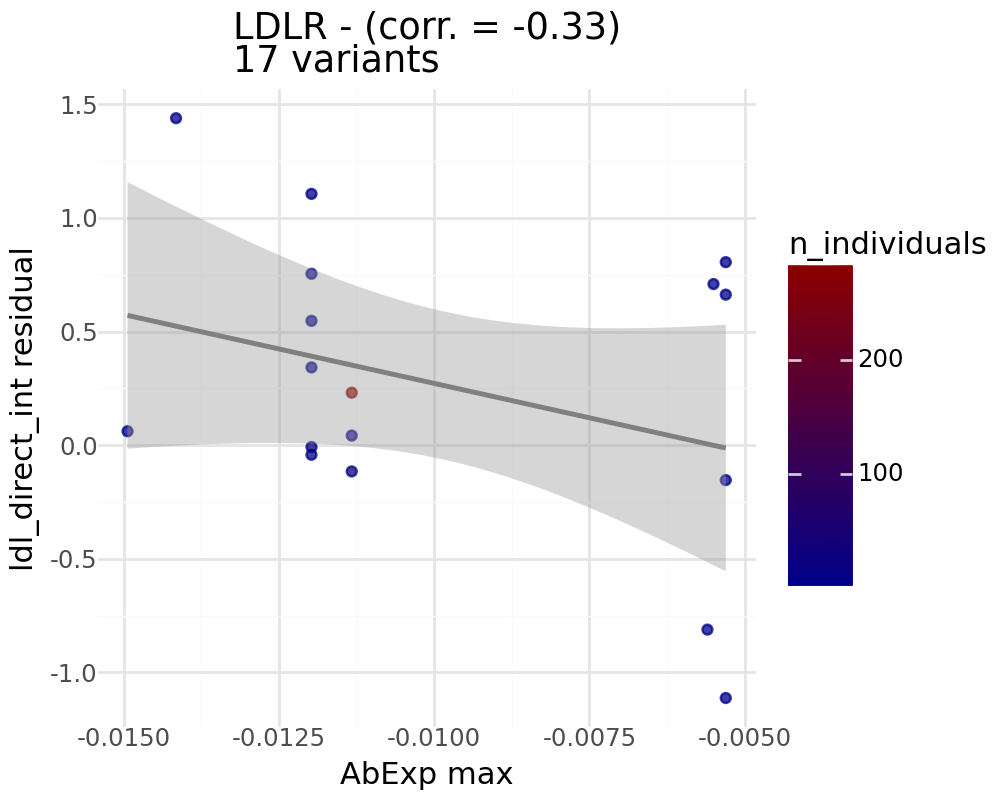

In [46]:
annotation = 'abexp_max'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)